# **0. Matériel : vérifier que le GPU est bien sélectionné !**

In [32]:
!nvidia-smi

Sun May 17 10:59:52 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0  On |                  N/A |
| 30%   52C    P2             108W / 350W |   2860MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# **1. Connexion à la plateforme Wandb**

Weights and Biases (W&B) est une plateforme qui permet de suivre, visualiser et partager les résultats d'expériences en temps réel. Veuillez créer un compte sur [https://wandb.ai/site](https://wandb.ai/site)

In [33]:
#import wandb
#wandb.login(key="4b4f1f26d14279d319ea32e2c41f7e9c5885ff7c")

# **2. Imports**

In [34]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import torchvision.models as models
import torchvision.transforms.v2 as transforms
from tqdm import tqdm

from torchmetrics import Accuracy
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image

# **4. Paramètres d'entrainement "Hyper-paramètres"**

> **Structure attendue du dataset :**
> ```
> images_dir/   ← toutes les images mélangées (.jpg, .png…)
> labels_dir/   ← fichiers .txt du même nom, format YOLO : <class_id> x y w h
> ```
> - `0` → Fire
> - `1` → Smoke
> - fichier vide (ou absent) → No_fire

In [35]:
# === Chemins vers tes dossiers ===
IMAGES_DIR = "/home/hackia_group/Data/D-Fire/train/images"   # dossier avec TOUTES les images mélangées
LABELS_DIR = "/home/hackia_group/Data/D-Fire/train/labels"   # dossier avec les .txt YOLO correspondants

# Dossier de test (même structure : images mélangées + labels)
TEST_IMAGES_DIR = "/home/hackia_group/Data/D-Fire/test/images"
TEST_LABELS_DIR = "/home/hackia_group/Data/D-Fire/test/labels"

Batch_size   = 16    #@param [8,16,32,64,128,256] {type:"raw"}
Epochs       = 100   #@param [1,5,10,20,50,100,200] {type:"raw"}
Learning_rate = 0.02 #@param [0.1,0.01,0.02,0.05,0.001,0.002,0.005] {type:"raw"}
Train_split  = 0.8   #@param [0.7,0.8,0.9] {type:"raw"}
Img_size     = 299   #@param [224,299] {type:"raw"}
Accelerator  = "gpu" #@param ["cpu","gpu","auto"]
num_classes  = 3
LOG_DIR      = "logs/"
log_folder   = "cnn"

# Correspondance label → index PyTorch
# 0 = Smoke, 1 = Fire, 2 = No_fire
CLASS_NAMES = ["smoke", "fire", "no_fire"]

# **5. Dataset personnalisé**

Comme les images sont toutes dans un seul dossier (pas de sous-dossiers par classe), on définit un `Dataset` qui lit les labels depuis les fichiers `.txt`.

In [36]:
class FireDataset(Dataset):
    """
    Dataset pour des images mélangées dans un seul dossier,
    avec labels YOLO dans un dossier séparé.

    Règle de labellisation :
      - Si le fichier .txt existe et contient au moins une ligne :
          → on prend le premier chiffre de la première ligne
            0 → Smoke, 1 → Fire
      - Si le fichier est absent ou vide → No_fire (classe 2)
    """
    IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform  = transform

        # Lister toutes les images
        self.samples = [
            f for f in os.listdir(images_dir)
            if os.path.splitext(f)[1].lower() in self.IMG_EXTENSIONS
        ]
        if len(self.samples) == 0:
            raise RuntimeError(f"Aucune image trouvée dans {images_dir}")
        print(f"Dataset chargé : {len(self.samples)} images depuis {images_dir}")

    def _get_label(self, img_filename):
        """Lit la classe depuis le fichier .txt correspondant."""
        stem      = os.path.splitext(img_filename)[0]
        label_path = os.path.join(self.labels_dir, stem + ".txt")

        if not os.path.exists(label_path):
            return 2  # No_fire

        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]

        if not lines:
            return 2  # No_fire

        # Le premier caractère de la première ligne = class_id
        first_char = lines[0][0]
        if first_char == "0":
            return 0  # Smoke
        elif first_char == "1":
            return 1  # Fire
        else:
            return 2  # No_fire par défaut

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname  = self.samples[idx]
        img_path = os.path.join(self.images_dir, fname)
        label  = self._get_label(fname)

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Vérification rapide de la distribution des classes ──────────────────────
def check_class_distribution(images_dir, labels_dir):
    ds = FireDataset(images_dir, labels_dir)
    counts = {0: 0, 1: 0, 2: 0}
    for _, label in ds:
        counts[label] += 1
    print("Distribution des classes :")
    for idx, name in enumerate(CLASS_NAMES):
        print(f"  {name} : {counts[idx]} images")
    return counts

# Décommentez pour vérifier avant d'entraîner :
# check_class_distribution(IMAGES_DIR, LABELS_DIR)

# **6. Afficher quelques images par classe**

Dataset chargé : 17221 images depuis /home/hackia_group/Data/D-Fire/train/images


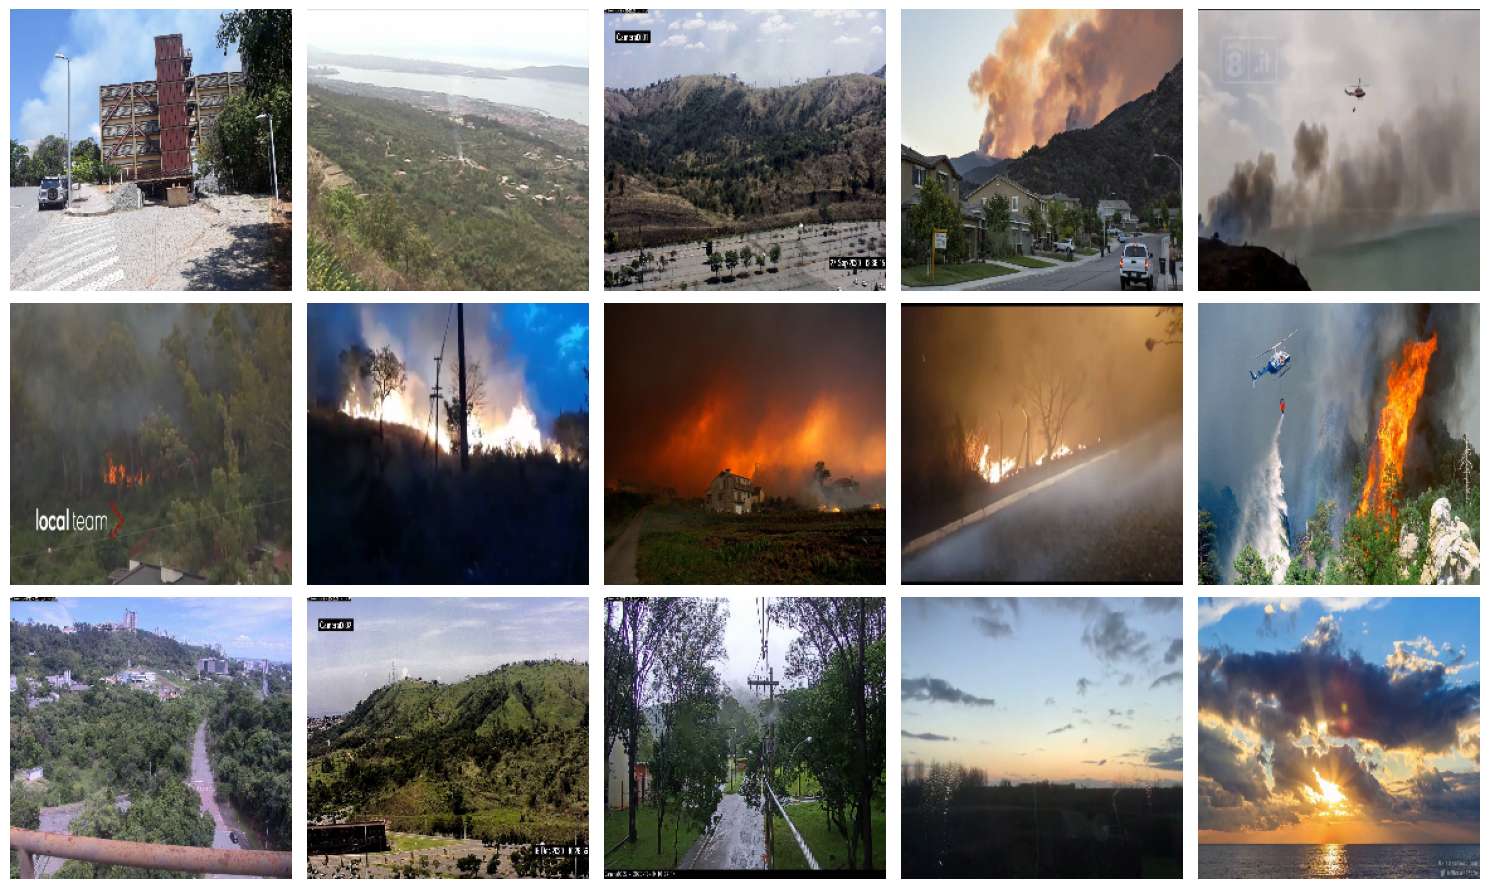

In [37]:
def display_samples(images_dir, labels_dir, n_per_class=5, img_size=224):
    ds = FireDataset(images_dir, labels_dir)
    buckets = {0: [], 1: [], 2: []}
    for fname in ds.samples:
        lbl = ds._get_label(fname)
        if len(buckets[lbl]) < n_per_class:
            buckets[lbl].append(os.path.join(images_dir, fname))
        if all(len(v) == n_per_class for v in buckets.values()):
            break

    fig, axes = plt.subplots(3, n_per_class, figsize=(15, 9))
    for row, (cls_idx, paths) in enumerate(buckets.items()):
        for col, path in enumerate(paths):
            img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            axes[row][col].imshow(img)
            axes[row][col].axis("off")
            if col == 0:
                axes[row][col].set_ylabel(CLASS_NAMES[cls_idx], fontsize=12)
    plt.tight_layout()
    plt.show()

display_samples(IMAGES_DIR, LABELS_DIR)

# **7. Définir le modèle (EfficientNet_v2_s + Transfer Learning)**

In [38]:
class FireDetectionModel(pl.LightningModule):
    def __init__(self, num_classes=num_classes, learning_rate=Learning_rate):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT)

        # Dégeler toutes les couches
        for param in self.model.parameters():
            param.requires_grad = True

        # Remplacer le classifier
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 500),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(500, 50),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(50, num_classes),
        )

        self.criterion     = nn.CrossEntropyLoss()
        self.learning_rate = learning_rate
        self.num_classes   = num_classes
        self.train_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy   = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy  = Accuracy(task="multiclass", num_classes=num_classes)

        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Paramètres entraînables : {trainable:,}")

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        preds = outputs.argmax(dim=1)
        self.train_accuracy(preds, labels)
        self.log_dict({"train_loss": loss, "train_acc": self.train_accuracy},
                      on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def on_train_epoch_end(self):
        self.train_accuracy.reset()

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        preds = outputs.argmax(dim=1)
        self.val_accuracy(preds, labels)
        self.log_dict({"val_loss": loss, "val_acc": self.val_accuracy},
                      on_step=False, on_epoch=True, prog_bar=True, logger=True)

    def on_validation_epoch_end(self):
        self.val_accuracy.reset()

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = F.cross_entropy(outputs, labels)
        preds = outputs.argmax(dim=1)
        self.test_accuracy(preds, labels)
        self.log_dict({"test_loss": loss, "test_acc": self.test_accuracy},
                      on_step=False, on_epoch=True, prog_bar=True, logger=True)

    def on_test_epoch_end(self):
        self.test_accuracy.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate,
                                    momentum=0.9, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=Epochs)
        return [optimizer], [scheduler]

# **8. Création des DataLoaders**

In [39]:
def create_data_loaders(images_dir, labels_dir,
                        test_images_dir, test_labels_dir,
                        batch_size, train_split, img_size):
    # Transforms entraînement (avec augmentation)
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

    # Transforms validation/test
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

    # ── Dataset principal (train + val) ────────────────────────────────────
    full_dataset_train = FireDataset(images_dir, labels_dir,
                                     transform=train_transform)
    full_dataset_val   = FireDataset(images_dir, labels_dir,
                                     transform=val_transform)

    n_total = len(full_dataset_train)
    n_train = int(np.floor(train_split * n_total))
    n_val   = n_total - n_train

    # On génère les indices une seule fois pour que train/val soient cohérents
    indices = list(range(n_total))
    np.random.shuffle(indices)
    train_idx, val_idx = indices[:n_train], indices[n_train:]

    from torch.utils.data import Subset
    train_dataset = Subset(full_dataset_train, train_idx)
    val_dataset   = Subset(full_dataset_val,   val_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    # ── Dataset de test ────────────────────────────────────────────────────
    test_dataset = FireDataset(test_images_dir, test_labels_dir,
                               transform=val_transform)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
    return train_loader, val_loader, test_loader

# **9. Sélection automatique du device**

In [40]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device utilisé :", device)

Device utilisé : cuda


# **10. Initialisation : dataloaders, modèle, callbacks, logger**

In [41]:
# ── DataLoaders ───────────────────────────────────────────────────────────
train_loader, val_loader, test_loader = create_data_loaders(
    IMAGES_DIR, LABELS_DIR,
    TEST_IMAGES_DIR, TEST_LABELS_DIR,
    Batch_size, Train_split, Img_size)

# ── Modèle ────────────────────────────────────────────────────────────────
model = FireDetectionModel(num_classes=num_classes, learning_rate=Learning_rate)

# ── Callbacks ─────────────────────────────────────────────────────────────
early_stop_callback = EarlyStopping(
    monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss", dirpath="checkpoints",
    filename="best-checkpoint", save_top_k=1, mode="min")

# ── Loggers ───────────────────────────────────────────────────────────────
# WandbLogger initialise wandb en interne — ne pas appeler wandb.init() séparément

csv_logger   = CSVLogger(LOG_DIR, name=log_folder, version="")

# ── Trainer ───────────────────────────────────────────────────────────────
# precision="16-mixed" (AMP) — utiliser "32" si le GPU ne supporte pas le fp16
trainer = pl.Trainer(
    max_epochs=Epochs,
    accelerator=Accelerator,
    devices=1,
    precision="16-mixed",          # fp16 mixed precision
    log_every_n_steps=1,
    logger=[csv_logger],
    callbacks=[checkpoint_callback, early_stop_callback],
)

Dataset chargé : 17221 images depuis /home/hackia_group/Data/D-Fire/train/images
Dataset chargé : 17221 images depuis /home/hackia_group/Data/D-Fire/train/images
Dataset chargé : 4306 images depuis /home/hackia_group/Data/D-Fire/test/images
Train : 13776 | Val : 3445 | Test : 4306


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Paramètres entraînables : 20,843,191


# **11. Lancer l'entraînement**

In [42]:
trainer.fit(model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/hackia_group/hackia/lib/python3.12/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory logs/cnn/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/hackia_group/hackia/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/hackia_group/Phase1/fire-detection/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/hackia_group/hackia/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not su

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model          │ EfficientNet       │ 20.8 M │ train │     0 │
│ 1 │ criterion      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 20.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.8 M                                                                                               
Total estimated model params size (MB): 83                                                                         
Modules in train mode: 723                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/hackia_group/hackia/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/hackia_group/hackia/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/hackia_group/hackia/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The 
``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, 
as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

Metric val_loss improved. New best score: 0.732
Metric val_loss improved by 0.084 >= min_delta = 0.0. New best score: 0.648
Metric val_loss improved by 0.085 >= min_delta = 0.0. New best score: 0.562
Metric val_loss improved by 0.024 >= min_delta = 0.0. New best score: 0.538
Metric val_loss improved by 0.039 >= min_delta = 0.0. New best score: 0.499
Metric val_loss improved by 0.064 >= min_delta = 0.0. New best score: 0.435
Metric val_loss improved by 0.047 >= min_delta = 0.0. New best score: 0.388
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 0.374
Metric val_loss improved by 0.051 >= min_delta = 0.0. New best score: 0.323
Monitored metric val_loss did not improve in the last 10 records. Best score: 0.323. Signaling Trainer to stop.


# **12. Évaluer le modèle**

In [12]:
print("=== Évaluation sur le train ===")
trainer.test(model, dataloaders=train_loader)

print("=== Évaluation sur la validation ===")
trainer.test(model, dataloaders=val_loader)

print("=== Évaluation sur le test ===")
trainer.test(model, dataloaders=test_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/hackia_group/hackia/lib/python3.12/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory logs/cnn/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== Évaluation sur le train ===


/home/hackia_group/hackia/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/hackia_group/hackia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


/home/hackia_group/hackia/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8961237072944641     │
│         test_loss         │    0.2534453272819519     │
└───────────────────────────┴───────────────────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9227866530418396     │
│         test_loss         │    0.18371373414993286    │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== Évaluation sur le test ===


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9050162434577942     │
│         test_loss         │     0.25239098072052      │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.25239098072052, 'test_acc': 0.9050162434577942}]

# **13. Courbes d'entraînement**

In [ ]:
def plot_metrics(LOG_DIR, log_folder):
    import pandas as pd
    df = pd.read_csv(f"{LOG_DIR}/{log_folder}/metrics.csv")
    train_df = df[df["train_loss_epoch"].notna()]
    val_df   = df[df["val_loss"].notna()]

    # Loss
    plt.figure(figsize=(10, 4))
    plt.plot(train_df["epoch"], train_df["train_loss_epoch"], label="Train Loss")
    plt.plot(val_df["epoch"],   val_df["val_loss"],           label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(train_df["epoch"], train_df["train_acc_epoch"], label="Train Acc")
    plt.plot(val_df["epoch"],   val_df["val_acc"],           label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plot_metrics(LOG_DIR, log_folder)

# **14. Tester le modèle sur une image isolée**

fire       : 1.67%
smoke      : 0.05%
no_fire    : 98.28%


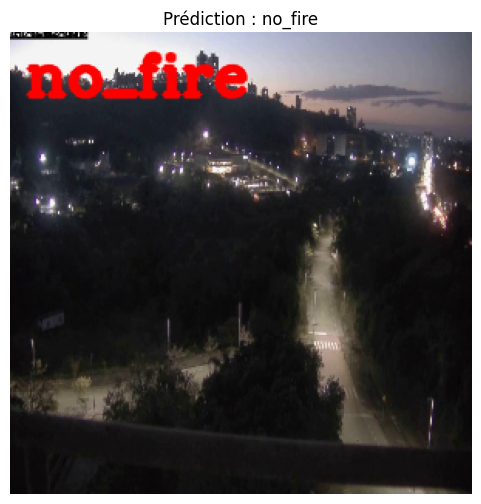

In [20]:
# Chemin vers une image de test
image_path = "/home/hackia_group/Data/D-Fire/test/images/AoF06801.jpg"   # ← adapter

img_pil = Image.open(image_path).convert("RGB")
infer_transform = transforms.Compose([
    transforms.Resize((Img_size, Img_size)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])
x = infer_transform(img_pil).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = model(x)
    probabilities = F.softmax(pred[0], dim=0)

img_cv = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
img_cv = cv2.resize(img_cv, (Img_size, Img_size))

for pos, prob in enumerate(probabilities):
    print(f"{CLASS_NAMES[pos]:10s} : {prob.item()*100:.2f}%")

best_class = CLASS_NAMES[probabilities.argmax().item()]
font = cv2.FONT_HERSHEY_COMPLEX
cv2.putText(img_cv, best_class, (10, 40), font, 1.2, (255, 0, 0), 3, cv2.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(img_cv)
plt.axis("off")
plt.title(f"Prédiction : {best_class}")
plt.show()

# **15. Sauvegarder / charger le modèle**

In [43]:
# ── Sauvegarde ───────────────────────────────────────────────────────────
torch.save(trainer.model.state_dict(), "/home/hackia_group/Data/D-Fire/FireForce_model.pth")
print("Modèle sauvegardé dans FireForce_model.pth")

Modèle sauvegardé dans FireForce_model.pth


In [44]:
# ── Chargement via .pth ───────────────────────────────────────────────────
#model = torch.load("/home/hackia_group/Data/D-Fire/fire_model.pth", weights_only=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FireDetectionModel(num_classes=3, learning_rate=Learning_rate)
model.load_state_dict(torch.load("/home/hackia_group/Data/D-Fire/FireForce_model.pth"))
model = model.to(device)  # ← modèle sur GPU
model.eval()

# ── Chargement via checkpoint Lightning ───────────────────────────────────
# model = FireDetectionModel.load_from_checkpoint("checkpoints/best-checkpoint.ckpt")
# model.eval()

Paramètres entraînables : 20,843,191


FireDetectionModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNo

# **16. Export vers Kaggle**

Pour le jeu de test Kaggle, les images sont dans un dossier sans labels (on n'a pas de `.txt`).

In [ ]:
import pandas as pd

def predict_folder(model, folder_path, img_size=224, save_to_csv=True):
    """Prédit la classe de chaque image dans un dossier (sans labels)."""
    model = model.to(device)
    model.eval()

    infer_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

    predictions, filenames = [], []
    IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for fname in tqdm(os.listdir(folder_path)):
        if os.path.splitext(fname)[1].lower() not in IMG_EXTENSIONS:
            continue
        img_path = os.path.join(folder_path, fname)
        image = Image.open(img_path).convert("RGB")
        image = infer_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image)
            pred   = output.argmax(dim=1).item()
        predictions.append(pred)
        filenames.append(fname)

    df = pd.DataFrame({"ID": filenames, "Label": predictions})
    if save_to_csv:
        df.to_csv("submission.csv", index=False)
        print("submission.csv sauvegardé.")
    return df

# Adapter le chemin vers le dossier d'images Kaggle
# submission = predict_folder(model, "test_data/TestData")
# display(submission.head())

# **17. Prédiction sur vidéo**

In [21]:
def save_mp4(imgs, output_path="output_video.mp4", fps=25):
    """Sauvegarde une liste d'images numpy (RGB) en MP4."""
    if not imgs:
        print("Aucune frame à écrire.")
        return
    height, width, _ = imgs[0].shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    for frame in imgs:
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    writer.release()
    print(f"Vidéo enregistrée : {output_path}")


def predict_from_video(model, classes, vid_dir="video/", img_dir="data/",
                       nbr_frame=10, output_path="output_video.mp4",
                       fps=25, plot=False):
    """Lit une vidéo, prédit la classe de chaque frame et génère une nouvelle vidéo."""
    os.makedirs(img_dir, exist_ok=True)
    model = model.to(device)
    model.eval()

    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

    for vid_file in os.listdir(vid_dir):
        vid_name = os.path.splitext(vid_file)[0]
        vid_path = os.path.join(vid_dir, vid_file)
        print(f"Traitement : {vid_path}")

        cap = cv2.VideoCapture(vid_path)
        if not cap.isOpened():
            print(f"Impossible d'ouvrir {vid_path}")
            continue

        frame_dir = os.path.join(img_dir, vid_name)
        os.makedirs(frame_dir, exist_ok=True)

        imgs, i = [], 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Sauter des frames
            for _ in range(nbr_frame - 1):
                cap.grab()

            img_path = os.path.join(frame_dir, f"{i}.png")
            cv2.imwrite(img_path, frame)
            i += 1

            image = Image.open(img_path).convert("RGB")
            tensor = infer_transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(tensor)
                probs = F.softmax(pred[0], dim=0)

            img_np = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            best_idx   = probs.argmax().item()
            class_name = classes[best_idx]

            font = cv2.FONT_HERSHEY_COMPLEX
            cv2.putText(img_np, class_name, (10, 50), font, 1.5,
                        (255, 0, 0), 4, cv2.LINE_AA)

            if plot:
                plt.imshow(img_np); plt.axis("off"); plt.show()

            imgs.append(img_np)

        cap.release()
        save_mp4(imgs, output_path, fps)


# predict_from_video(model, CLASS_NAMES, fps=15, nbr_frame=5,
#                    output_path="output_video/output_video.mp4")

# **18. Explicabilité – GradCAM**

In [48]:
# !pip install captum
from captum.attr import LayerGradCam
import matplotlib.patheffects as pe
from matplotlib.backends.backend_agg import FigureCanvasAgg
import torchvision.transforms.v2 as transforms

def get_last_conv_layer(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    if last_conv is None:
        raise ValueError("Aucune couche Conv2d trouvée.")
    return last_conv

def frame_to_np(frame_rgb):
    """Convertit une frame RGB numpy en figure matplotlib puis en np array — pour les frames sans GradCAM."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(frame_rgb)
    ax.axis("off")
    plt.tight_layout()
    arr = fig_to_np(fig)
    plt.close(fig)
    return arr

def visualize_gradcam(model, inputs, labels, figsize=(8, 8)):
    last_conv = get_last_conv_layer(model)
    gradcam   = LayerGradCam(model, last_conv)

    target = int(labels) if not isinstance(labels, int) else labels
    attribution = gradcam.attribute(inputs, target=target,
                                    relu_attributions=True)

    inputs_np = inputs[0].cpu().permute(1, 2, 0).detach().numpy()
    heatmap   = attribution[0, 0].cpu().detach().numpy()
    heatmap   = cv2.resize(heatmap, (inputs_np.shape[1], inputs_np.shape[0]))
    heatmap   = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(inputs_np)
    ax.imshow(heatmap, alpha=0.5, cmap="jet")
    ax.axis("off")
    ax.set_title("GradCAM")
    plt.tight_layout()
    return fig, ax

def visualize_gradcam(model, inputs, labels, original_frame=None):
    last_conv   = get_last_conv_layer(model)
    gradcam     = LayerGradCam(model, last_conv)
    target      = int(labels) if not isinstance(labels, int) else labels
    attribution = gradcam.attribute(inputs, target=target, relu_attributions=True)

    # Utiliser la frame originale si disponible, sinon le tensor redimensionné
    if original_frame is not None:
        base_img = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)  # (H, W, 3) uint8
    else:
        base_img = (inputs[0].cpu().permute(1, 2, 0).detach().numpy() * 255).astype(np.uint8)

    h, w = base_img.shape[:2]

    # Heatmap → même taille que la frame originale
    heatmap = attribution[0, 0].cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    heatmap = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay direct en numpy — pas de matplotlib
    overlay = cv2.addWeighted(base_img, 1.0, heatmap_colored, 0.5, 0)
    return overlay  # np.array (H, W, 3) RGB, même taille que la vidéo source


def fig_to_np(fig):
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    buf = canvas.buffer_rgba()
    w, h = fig.canvas.get_width_height()
    return np.asarray(buf).reshape(h, w, 4)[..., :3]


def predict_from_video_gradcam(model, classes, vid_dir="/home/hackia_group/Data/video/", img_dir="data/",
                                nbr_frame=10, output_dir="Results/",
                                fps=25, plot=False):
    os.makedirs(img_dir, exist_ok=True)
    model = model.to(device)
    model.eval()

    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

    for vid_file in os.listdir(vid_dir):
        vid_name = os.path.splitext(vid_file)[0]
        vid_path = os.path.join(vid_dir, vid_file)
        print(f"Traitement : {vid_path}")
        output_path = os.path.join(output_dir, vid_name + '_gradcam.mp4')

        cap = cv2.VideoCapture(vid_path)
        if not cap.isOpened():
            print(f"Impossible d'ouvrir {vid_path}")
            continue

        frame_dir = os.path.join(img_dir, vid_name)
        os.makedirs(frame_dir, exist_ok=True)

        figs, i = [], 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            for _ in range(nbr_frame - 1):
                cap.grab()

            img_path = os.path.join(frame_dir, f"{i}.png")
            cv2.imwrite(img_path, frame)
            i += 1

            image  = Image.open(img_path).convert("RGB")
            tensor = infer_transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                pred  = model(tensor)
                probs = F.softmax(pred[0], dim=0)                

            best_idx   = probs.argmax().item()
            class_name = classes[best_idx]

            # ── CONDITION GRADCAM ──────────────────────────────────────────
            if (best_idx == 0) | (best_idx == 1) & (float(f"{probs[best_idx]*100:.1f}") > 65):  # FIRE → GradCAM
                overlay = visualize_gradcam(model, tensor, best_idx, original_frame=frame)
                # Ajouter le titre directement avec OpenCV
                label_text = f"{class_name} ({probs[best_idx]*100:.1f}%)"
                cv2.putText(overlay, label_text, (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
                if plot:
                    plt.imshow(overlay); plt.axis("off"); plt.show()
                figs.append(overlay)
                #fig, ax = visualize_gradcam(model, tensor, best_idx)
                #ax.set_title(f"{class_name} ({probs[best_idx]*100:.1f}%)", fontsize=14)
                #if plot:
                #    plt.show()
                #figs.append(fig_to_np(fig))
                #plt.close(fig)
            else:              # no_fire / smoke → frame intacte
                figs.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                #frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                #figs.append(frame_to_np(frame_rgb))
            # ──────────────────────────────────────────────────────────────

        cap.release()

        # Sauvegarder la vidéo GradCAM
        if figs:
            h, w, _ = figs[0].shape
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
            for frame_np in figs:
                writer.write(cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR))
            writer.release()
            print(f"Vidéo GradCAM enregistrée : {output_path}")


predict_from_video_gradcam(model, CLASS_NAMES, fps=15, nbr_frame=5,
                           output_dir="/home/hackia_group/Data/Results/")

Traitement : /home/hackia_group/Data/video/videofeu.mp4
Vidéo GradCAM enregistrée : /home/hackia_group/Data/Results/videofeu_gradcam.mp4
Traitement : /home/hackia_group/Data/video/IMG_5068.MOV
Vidéo GradCAM enregistrée : /home/hackia_group/Data/Results/IMG_5068_gradcam.mp4
Traitement : /home/hackia_group/Data/video/Fire_video.mp4
Vidéo GradCAM enregistrée : /home/hackia_group/Data/Results/Fire_video_gradcam.mp4
Traitement : /home/hackia_group/Data/video/IMG_5069.MOV
Vidéo GradCAM enregistrée : /home/hackia_group/Data/Results/IMG_5069_gradcam.mp4
Traitement : /home/hackia_group/Data/video/FireVideo.mp4
Vidéo GradCAM enregistrée : /home/hackia_group/Data/Results/FireVideo_gradcam.mp4


# Metric Pointing games

In [46]:
!pip install quantus

In [71]:
import quantus
from torchvision import transforms
from captum.attr import LayerGradCam

def parse_yolo_label(label_path, img_w, img_h):
    """
    Parse un fichier label YOLO et retourne les bounding boxes en pixels.
    Retourne une liste de (x_min, y_min, x_max, y_max).
    """
    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts)
            x_min = int((cx - bw / 2) * img_w)
            y_min = int((cy - bh / 2) * img_h)
            x_max = int((cx + bw / 2) * img_w)
            y_max = int((cy + bh / 2) * img_h)
            boxes.append((x_min, y_min, x_max, y_max))
    return boxes


def boxes_to_segmentation_mask(boxes, img_h, img_w):
    """
    Convertit une liste de bounding boxes en masque binaire (H, W).
    1 à l'intérieur des boxes, 0 ailleurs.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    for (x_min, y_min, x_max, y_max) in boxes:
        mask[y_min:y_max, x_min:x_max] = 1
    return mask  # (H, W)


def compute_gradcam_attribution(model, tensor, target_class):
    """
    Calcule la carte GradCAM pour une image et retourne un np.array (H, W).
    """
    last_conv   = get_last_conv_layer(model)
    gradcam     = LayerGradCam(model, last_conv)
    attribution = gradcam.attribute(tensor, target=target_class, relu_attributions=True)

    heatmap = attribution[0, 0].cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Redimensionner à la taille d'entrée du modèle (224x224)
    heatmap = cv2.resize(heatmap, (tensor.shape[3], tensor.shape[2]))
    return heatmap  # (H, W) float [0, 1]


def compute_pointing_game(model, images_dir, labels_dir, img_size=224, device="cuda"):
    """
    Calcule le Pointing Game score sur tout le dataset.
    Ne traite que les images ayant au moins une bounding box (fire/smoke).
    """
    model = model.to(device)
    model.eval()

    infer_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    all_attributions = []  # (N, 1, H, W)
    all_masks        = []  # (N, 1, H, W)
    all_inputs       = []  # (N, 3, H, W)
    all_targets      = []  # (N,)

    print("Calcul des attributions GradCAM...")
    for img_file in image_files:
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)

        # Ignorer les fichiers vides (no_fire, pas de bounding box)
        with open(label_path, 'r') as f:
            content = f.read().strip()
        if not content:
            continue

        # Charger et transformer l'image
        img_path = os.path.join(images_dir, img_file)
        image    = Image.open(img_path).convert("RGB")
        tensor   = infer_transform(image).unsqueeze(0).to(device)

        # Prédiction
        with torch.no_grad():
            pred  = model(tensor)
            probs = torch.softmax(pred[0], dim=0)
        best_idx = probs.argmax().item()

        # GradCAM
        heatmap = compute_gradcam_attribution(model, tensor, best_idx)  # (H, W)

        # Bounding boxes → masque binaire à la taille du modèle
        boxes = parse_yolo_label(label_path, img_w=img_size, img_h=img_size)
        mask  = boxes_to_segmentation_mask(boxes, img_h=img_size, img_w=img_size)  # (H, W)

        # Accumuler — Quantus attend (N, C, H, W)
        all_attributions.append(heatmap[np.newaxis, np.newaxis, :, :])        # (1, 1, H, W)
        all_masks.append(mask[np.newaxis, np.newaxis, :, :])                  # (1, 1, H, W)
        all_inputs.append(tensor[0].cpu().numpy()[np.newaxis, :, :, :])       # (1, 3, H, W)
        all_targets.append(best_idx)

    if not all_attributions:
        print("Aucune image avec bounding box trouvée.")
        return None

    # Concaténer en arrays (N, ...)
    all_attributions = np.concatenate(all_attributions, axis=0)  # (N, 1, H, W)
    all_masks        = np.concatenate(all_masks,        axis=0)  # (N, 1, H, W)
    all_inputs       = np.concatenate(all_inputs,       axis=0)  # (N, 3, H, W)
    all_targets      = np.array(all_targets)                      # (N,)

    print(f"Nombre d'images évaluées : {len(all_targets)}")

    # Calcul Pointing Game via Quantus
    metric = quantus.PointingGame(
        abs=False,
        normalise=True,
        normalise_func=quantus.normalise_by_max,
        return_aggregate=True,
    )

    scores = metric(
        model=model,
        x_batch=all_inputs,
        y_batch=all_targets,
        a_batch=all_attributions,
        s_batch=all_masks,
        device=device,
        explain_func=None,   # on fournit a_batch directement
    )

    print(f"\nPointing Game Score : {scores}")
    return scores


# Appel
score = compute_pointing_game(
    model=model,
    images_dir="/home/hackia_group/Data/D-Fire/test/images",
    labels_dir="/home/hackia_group/Data/D-Fire/test/labels",
    img_size=224,
    device=device
)

Calcul des attributions GradCAM...
Nombre d'images évaluées : 2301

Pointing Game Score : [np.float64(0.4654498044328553)]


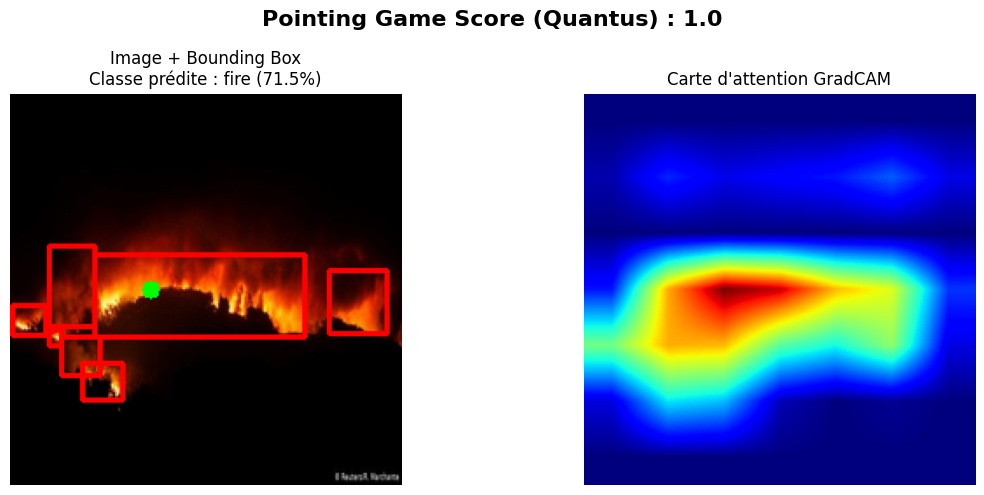

[np.float64(1.0)]

In [70]:
def visualize_pointing_game_sample(model, img_path, label_path, img_size=224, device="cuda"):
    infer_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    # Charger l'image
    image  = Image.open(img_path).convert("RGB")
    tensor = infer_transform(image).unsqueeze(0).to(device)

    # Prédiction
    with torch.no_grad():
        pred  = model(tensor)
        probs = torch.softmax(pred[0], dim=0)
    best_idx = probs.argmax().item()

    # GradCAM
    heatmap = compute_gradcam_attribution(model, tensor, best_idx)  # (H, W) float [0,1]

    # Bounding boxes → masque
    boxes = parse_yolo_label(label_path, img_w=img_size, img_h=img_size)
    mask  = boxes_to_segmentation_mask(boxes, img_h=img_size, img_w=img_size)

    # ── Calcul Pointing Game via Quantus sur cette seule image ──
    attribution_batch = heatmap[np.newaxis, np.newaxis, :, :]          # (1, 1, H, W)
    mask_batch        = mask[np.newaxis, np.newaxis, :, :].astype(int) # (1, 1, H, W)
    input_batch       = tensor[0].cpu().numpy()[np.newaxis, :, :, :]   # (1, 3, H, W)
    target_batch      = np.array([best_idx])                           # (1,)

    metric = quantus.PointingGame(
        abs=False,
        normalise=True,
        normalise_func=quantus.normalise_by_max,
        return_aggregate=True,
    )
    pg_score = metric(
        model=model,
        x_batch=input_batch,
        y_batch=target_batch,
        a_batch=attribution_batch,
        s_batch=mask_batch,
        device=device,
        explain_func=None,
    )

    # ── Image avec bounding boxes ──
    img_resized    = np.array(image.resize((img_size, img_size)))
    img_with_boxes = img_resized.copy()
    for (x_min, y_min, x_max, y_max) in boxes:
        cv2.rectangle(img_with_boxes,
                      (x_min, y_min), (x_max, y_max),
                      color=(255, 0, 0), thickness=2)

    # Point max de la heatmap
    max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    cv2.circle(img_with_boxes, (max_idx[1], max_idx[0]),
               radius=5, color=(0, 255, 0), thickness=-1)

    # ── Figure ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_with_boxes)
    axes[0].axis("off")
    axes[0].set_title(f"Image + Bounding Box\nClasse prédite : {CLASS_NAMES[best_idx]} ({probs[best_idx]*100:.1f}%)")

    axes[1].imshow(heatmap, cmap="jet")
    axes[1].axis("off")
    axes[1].set_title("Carte d'attention GradCAM")

    fig.suptitle(f"Pointing Game Score (Quantus) : {pg_score[0]}", fontsize=16, fontweight="bold")

    plt.tight_layout()
    plt.show()
    return pg_score



# ── Appel sur une image ──
visualize_pointing_game_sample(
    model=model,
    img_path="/home/hackia_group/Data/D-Fire/test/images/WEB11803.jpg",
    label_path="/home/hackia_group/Data/D-Fire/test/labels/WEB11803.txt",
    img_size=224,
    device=device
)